# Data

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from data_generator import generate_dataset

In [2]:
data = generate_dataset(n_pde=2000)

### Тренировочные данные

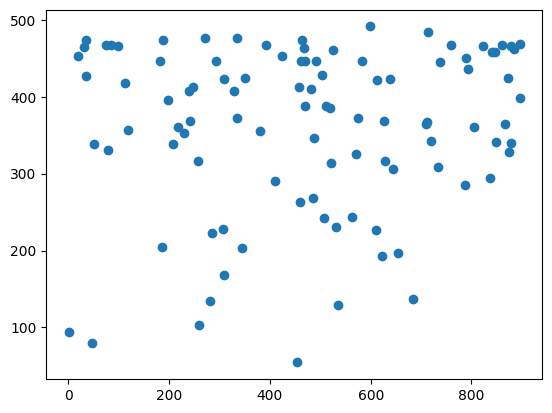

In [4]:
import matplotlib.pyplot as plt 
plt.scatter(data['t_train'], data['S_train'])
plt.show()

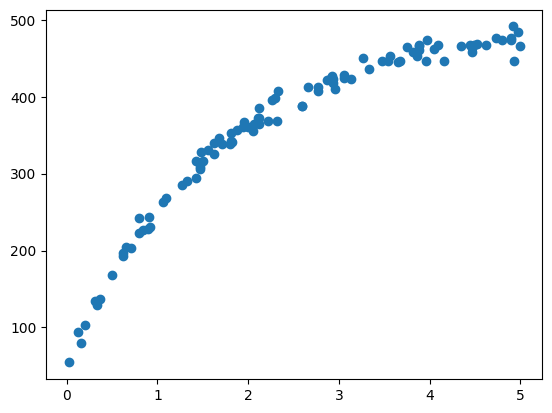

In [5]:
plt.scatter(data['z_train'], data['S_train'])
plt.show()

### Тестовые данные (непрерывные)

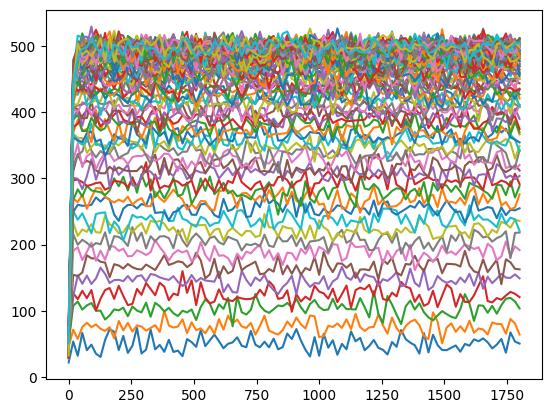

In [3]:
import matplotlib.pyplot as plt 
plt.plot(data['t_test'], data['S_test'])
plt.show()

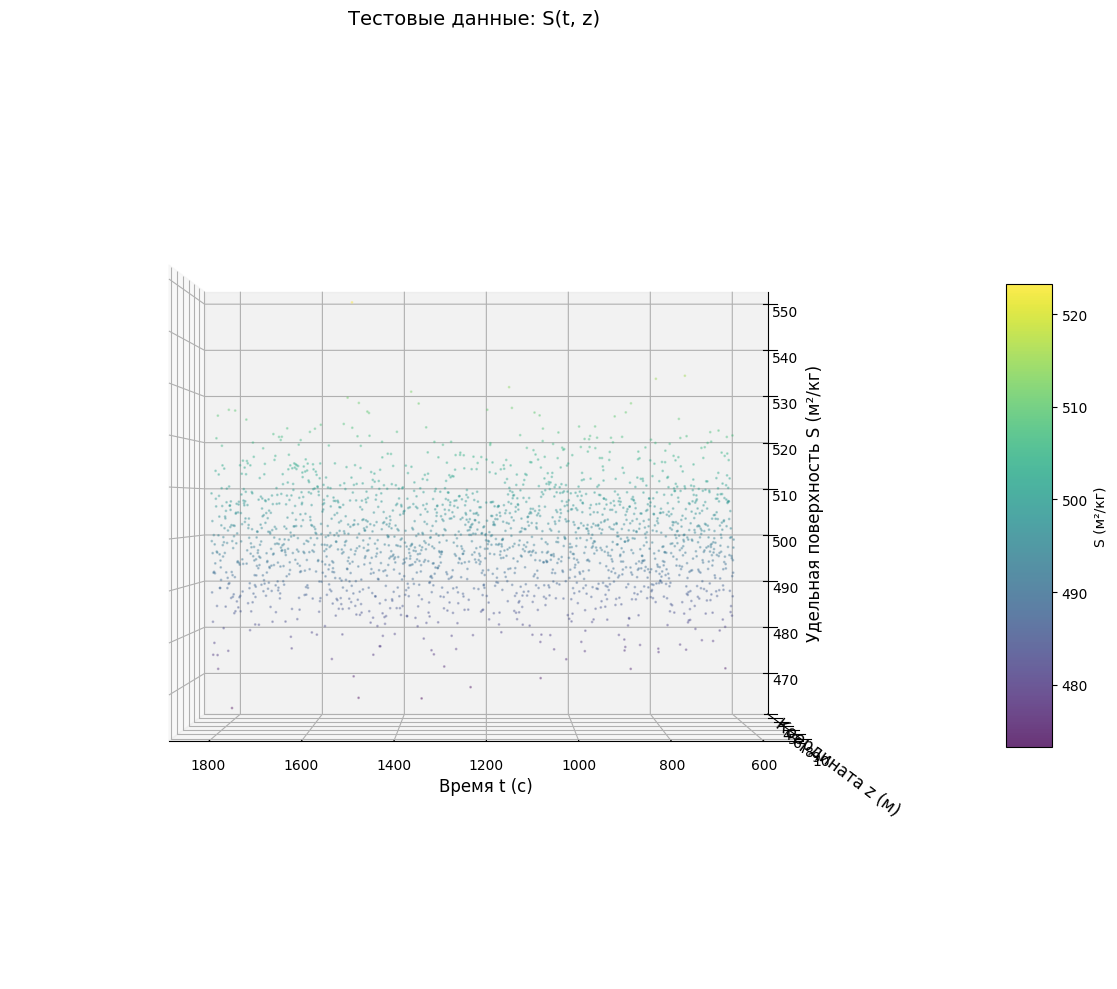

In [7]:
t_test = data['t_test'].detach().numpy().flatten()
z_test = data['z_test'].detach().numpy().flatten()
S_test = data['S_test'].detach().numpy().flatten()

# Создаем регулярную сетку для интерполяции
t_grid = np.linspace(t_test.min(), t_test.max(), 50)
z_grid = np.linspace(z_test.min(), z_test.max(), 50)
T, Z = np.meshgrid(t_grid, z_grid)

# Интерполируем данные на регулярную сетку
S_grid = griddata((t_test, z_test), S_test, (T, Z), method='cubic')

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S_grid, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
            s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=0,  
            azim=90)
plt.show()

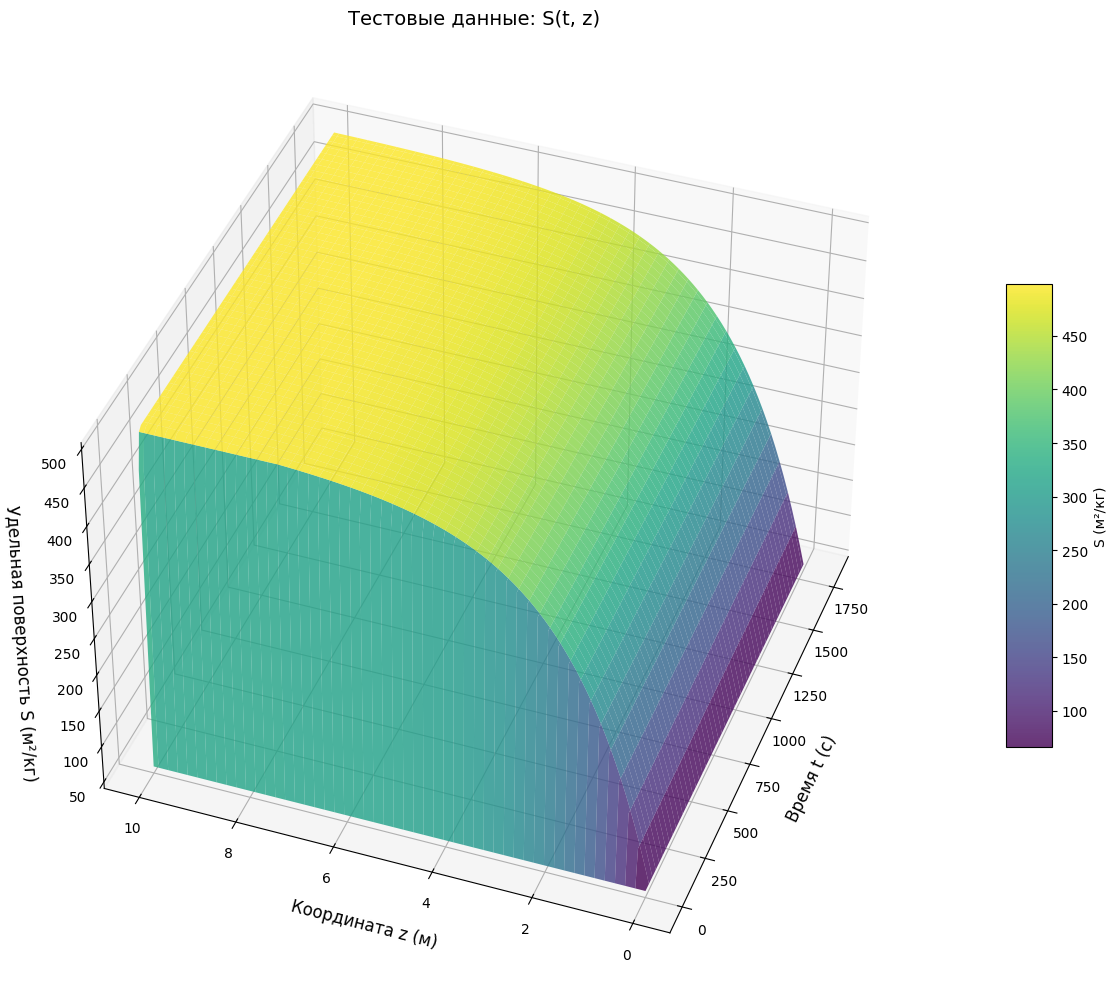

In [20]:
T, Z, S = data["T"].numpy(), data["Z"].numpy(), data["S"]

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
# ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
#             s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=40,  # вращение в вертикальной плоскости
            azim=200) # вращение в горизантальной плоскости
plt.show()

# PINN

In [3]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.PINN import PINN
from loss.pinn_loss import pinn_loss

## PINN, обученная с заданными коэффициентами

k = 0.12 <br>
v_m = 0.2 <br>
epochs = 30_000

### все параметры (включая mse)

 lambda_pde=3.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [ ]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=4.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 512323.344
Epoch 100 | Loss: 480226.250
Epoch 200 | Loss: 458416.688
Epoch 300 | Loss: 438576.938
Epoch 400 | Loss: 420110.875
Epoch 500 | Loss: 402837.719
Epoch 600 | Loss: 386647.250
Epoch 700 | Loss: 370972.438
Epoch 800 | Loss: 355884.969
Epoch 900 | Loss: 341524.406
Epoch 1000 | Loss: 327854.312
Epoch 1100 | Loss: 314848.719
Epoch 1200 | Loss: 302480.750
Epoch 1300 | Loss: 290719.344
Epoch 1400 | Loss: 279542.625
Epoch 1500 | Loss: 268948.750
Epoch 1600 | Loss: 258916.969
Epoch 1700 | Loss: 249428.594
Epoch 1800 | Loss: 240464.203
Epoch 1900 | Loss: 231996.422
Epoch 2000 | Loss: 223991.766
Epoch 2100 | Loss: 216450.219
Epoch 2200 | Loss: 209361.578
Epoch 2300 | Loss: 202704.078
Epoch 2400 | Loss: 196472.969
Epoch 2500 | Loss: 190648.891
Epoch 2600 | Loss: 185222.938
Epoch 2700 | Loss: 180175.500
Epoch 2800 | Loss: 175494.031
Epoch 2900 | Loss: 171164.078
Epoch 3000 | Loss: 167161.750
Epoch 3100 | Loss: 144068.969
Epoch 3200 | Loss: 122115.383
E

In [10]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

### без MSE

lambda_pde=2.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=0.<br>

In [11]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=2.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=0.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    S_pred = pinn(data['t_train'], data['z_train'])
    diff = data["S_train"] - S_pred

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | diff: {torch.mean(diff**2)}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 12208.944 | diff: 248000.6875
Epoch 100 | Loss: 9204.741 | diff: 233293.65625
Epoch 200 | Loss: 7780.582 | diff: 224227.796875
Epoch 300 | Loss: 6893.516 | diff: 216883.484375
Epoch 400 | Loss: 6355.116 | diff: 210951.921875
Epoch 500 | Loss: 6047.575 | diff: 206282.953125
Epoch 600 | Loss: 5884.697 | diff: 202739.078125
Epoch 700 | Loss: 5805.472 | diff: 200160.921875
Epoch 800 | Loss: 5770.278 | diff: 198370.296875
Epoch 900 | Loss: 5755.989 | diff: 197184.875
Epoch 1000 | Loss: 5750.560 | diff: 196437.0
Epoch 1100 | Loss: 5747.776 | diff: 195982.921875
Epoch 1200 | Loss: 5700.937 | diff: 194956.234375
Epoch 1300 | Loss: 5683.094 | diff: 193542.59375
Epoch 1400 | Loss: 5674.049 | diff: 192460.90625
Epoch 1500 | Loss: 5668.344 | diff: 191652.875
Epoch 1600 | Loss: 5664.445 | diff: 191055.359375
Epoch 1700 | Loss: 5661.754 | diff: 190630.359375
Epoch 1800 | Loss: 5660.145 | diff: 190351.515625
Epoch 1900 | Loss: 5659.197 | diff: 190185.34375
Epoch 2

In [12]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_pde.pth'))

### без pde

lambda_pde=0.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [15]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=0.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 502019.625
Epoch 100 | Loss: 469002.062
Epoch 200 | Loss: 448028.906
Epoch 300 | Loss: 428747.781
Epoch 400 | Loss: 410769.750
Epoch 500 | Loss: 393945.031
Epoch 600 | Loss: 378181.656
Epoch 700 | Loss: 363383.625
Epoch 800 | Loss: 348384.250
Epoch 900 | Loss: 334319.875
Epoch 1000 | Loss: 320931.375
Epoch 1100 | Loss: 308201.688
Epoch 1200 | Loss: 296105.750
Epoch 1300 | Loss: 284621.844
Epoch 1400 | Loss: 273729.156
Epoch 1500 | Loss: 263407.500
Epoch 1600 | Loss: 253637.031
Epoch 1700 | Loss: 244396.125
Epoch 1800 | Loss: 235669.828
Epoch 1900 | Loss: 227427.609
Epoch 2000 | Loss: 217934.781
Epoch 2100 | Loss: 201015.359
Epoch 2200 | Loss: 188850.938
Epoch 2300 | Loss: 177509.531
Epoch 2400 | Loss: 167230.516
Epoch 2500 | Loss: 163123.062
Epoch 2600 | Loss: 148728.234
Epoch 2700 | Loss: 139637.344
Epoch 2800 | Loss: 131213.828
Epoch 2900 | Loss: 123659.680
Epoch 3000 | Loss: 115587.242
Epoch 3100 | Loss: 151286.516
Epoch 3200 | Loss: 101744.609
E

In [16]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse.pth'))

### Визуализация 3х моделей

In [216]:
# --- MSE PDE ---
pinn_mse_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn_mse_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_mse_pde.eval()

# --- MSE ---
pinn_mse = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse.pth"))
pinn_mse.load_state_dict(checkpoint["model_state_dict"])

pinn_mse.eval()

# --- PDE ---
pinn_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_pde.pth"))
pinn_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_pde.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

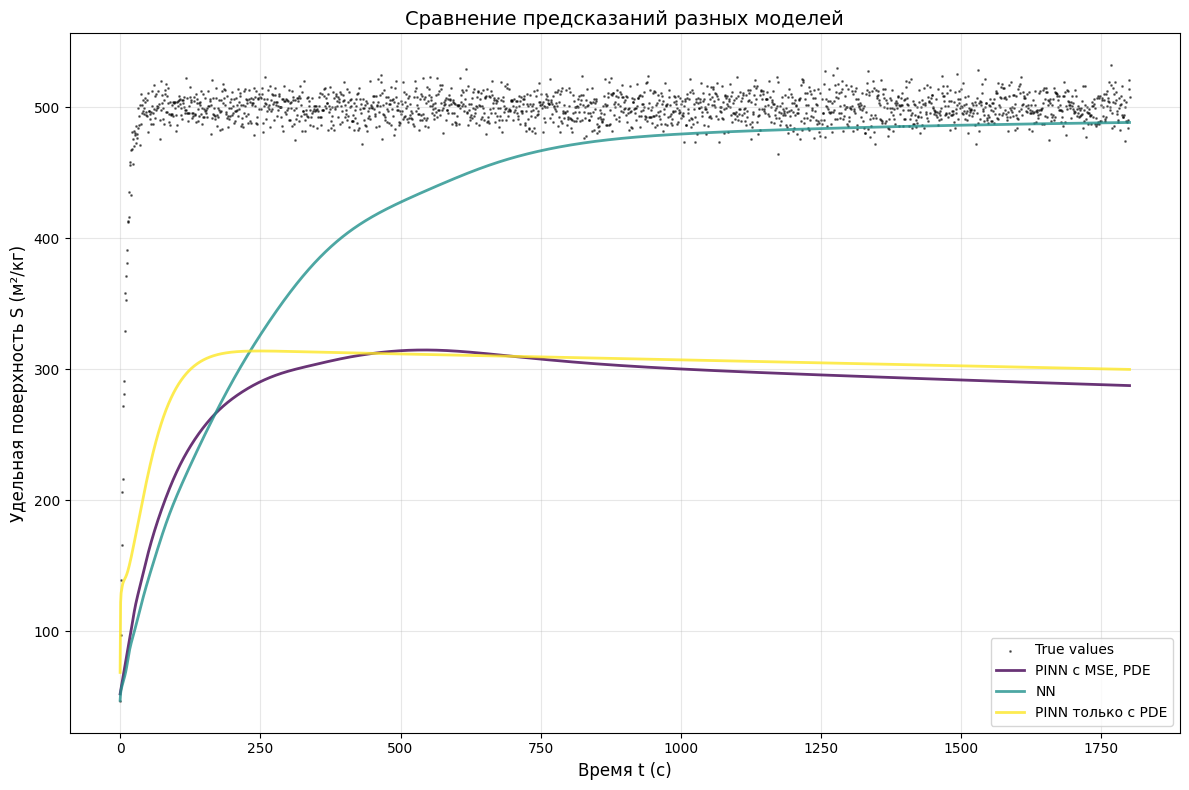

In [ ]:
# неактуальный график
plt.figure(figsize=(12, 8))
t_test = data['t_train'].detach().numpy().flatten()
z_test = data['z_train'].detach().numpy().flatten()
S_test = data['S_train'].detach().numpy().flatten()
models = [pinn_mse_pde, pinn_mse, pinn_pde]
model_names = ['PINN с MSE, PDE', 'NN', 'PINN только с PDE']

# Строим истинные значения
plt.scatter(t_test, S_test, s=1, alpha=0.5, 
               color='black', label='True values')
    
# Строим предсказания каждой модели
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    S_pred = model(data['t_train'], data['z_train']).detach().numpy().flatten()
    plt.plot(t_test, S_pred, linewidth=2, 
                color=colors[i], label=name, alpha=0.8)

plt.xlabel('Время t (с)', fontsize=12)
plt.ylabel('Удельная поверхность S (м²/кг)', fontsize=12)
plt.title('Сравнение предсказаний разных моделей', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [220]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

def plot_multiple_pinns(models_dict, t_max=1800.0, z_max=10.0, v_m=0.2, k=0.12, S_max=500.0, S0=50.0):
    """
    Строит сравнительные графики для нескольких моделей.
    
    Аргументы:
        models_dict (dict): Словарь вида {'Имя модели 1': model1, 'Имя модели 2': model2}
    """
    # 1. Создаем равномерную сетку
    n_points = 100
    t_lin = np.linspace(0, t_max, n_points)
    z_lin = np.linspace(0, z_max, n_points)
    T, Z = np.meshgrid(t_lin, z_lin, indexing='ij')

    # 2. Вычисляем точное аналитическое решение
    tau = T - Z / v_m
    S_exact = np.where(
        tau > 0,
        S_max - (S_max - S0) * np.exp(-k * Z / v_m),
        S_max - (S_max - S0) * np.exp(-k * T)
    )
    # S_exact = data['S_test']

    # 3. Подготовка тензоров для моделей
    T_tensor = torch.tensor(T, dtype=torch.float32).flatten().unsqueeze(1)
    Z_tensor = torch.tensor(Z, dtype=torch.float32).flatten().unsqueeze(1)

    # 4. Собираем предсказания всех моделей
    predictions = {}
    for name, model in models_dict.items():
        S_pred_tensor = model.predict(T_tensor, Z_tensor)
        predictions[name] = S_pred_tensor.numpy().reshape(T.shape)

    # Палитра контрастных цветов для разных моделей
    colors = ['crimson', 'forestgreen', 'darkorange', 'purple', 'teal']
    
    # ==========================================
    # ПОСТРОЕНИЕ ГРАФИКОВ
    # ==========================================
    
    # --- График 1: 3D Сравнение ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Поверхность аналитики (полупрозрачная синяя)
    ax.plot_surface(T, Z, S_exact, alpha=0.3, color='royalblue')
    
    # Подготавливаем элементы для легенды 3D графика
    custom_lines = [Line2D([0], [0], color='royalblue', lw=10, alpha=0.4)]
    legend_labels = ['Аналитическое решение']

    # Наносим сетки предсказаний для каждой модели
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        # rstride/cstride задают густоту сетки. 
        ax.plot_wireframe(T, Z, S_pred, color=color, alpha=0.7, rstride=5, cstride=5)
        custom_lines.append(Line2D([0], [0], color=color, lw=2))
        legend_labels.append(name)
    
    ax.set_xlabel('Время t, с')
    ax.set_ylabel('Координата z, м')
    ax.set_zlabel('Удельная поверхность S, м2/кг')
    ax.set_zlim(bottom=0)
    ax.set_title('Сравнение нескольких PINN моделей (3D)')
    ax.legend(custom_lines, legend_labels, loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Графики 2 и 3: Плоские срезы (2D) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Срез A: По координате Z в фиксированный момент времени T
    t_idx = n_points // 3*2 # Середина процесса (t = 900 с)
    current_t = t_lin[t_idx]
    
    # Рисуем аналитику жирной полупрозрачной линией
    # axes[0].plot(z_lin, S_exact[t_idx, :], color='royalblue', linewidth=4, alpha=0.4, label='Аналитика')
    axes[0].scatter(z_lin, S_exact[t_idx, :], color='royalblue', alpha=0.5, label='Аналитика')
    
    # Наносим предсказания моделей пунктиром
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[0].plot(z_lin, S_pred[t_idx, :], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[0].set_xlabel('Координата в мельнице z, м')
    axes[0].set_ylabel('Удельная поверхность S, м2/кг')
    axes[0].set_title(f'Профиль S(z) в момент времени t = {current_t:.0f} с')
    axes[0].grid(True, linestyle=':', alpha=0.7)
    axes[0].legend()

    # Срез B: Во времени T в фиксированной координате Z (на выходе)
    z_idx = -1 # Конец мельницы (z = 10 м)
    current_z = z_lin[z_idx]
    
    axes[1].scatter(t_lin, S_exact[:, z_idx], color='royalblue', alpha=0.5, label='Аналитика')
    
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[1].plot(t_lin, S_pred[:, z_idx], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[1].set_xlabel('Время t, с')
    axes[1].set_ylabel('Удельная поверхность S, м2/кг')
    axes[1].set_title(f'Динамика S(t) на выходе из мельницы (z = {current_z:.1f} м)')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

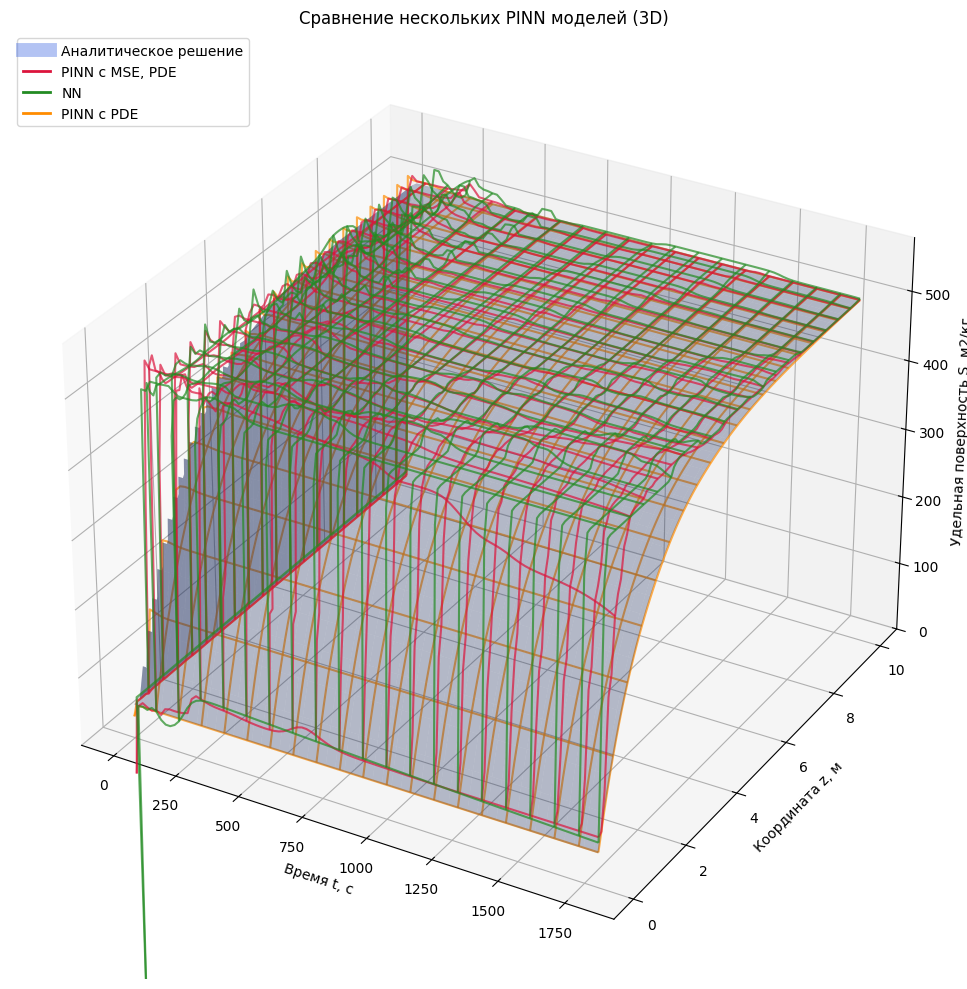

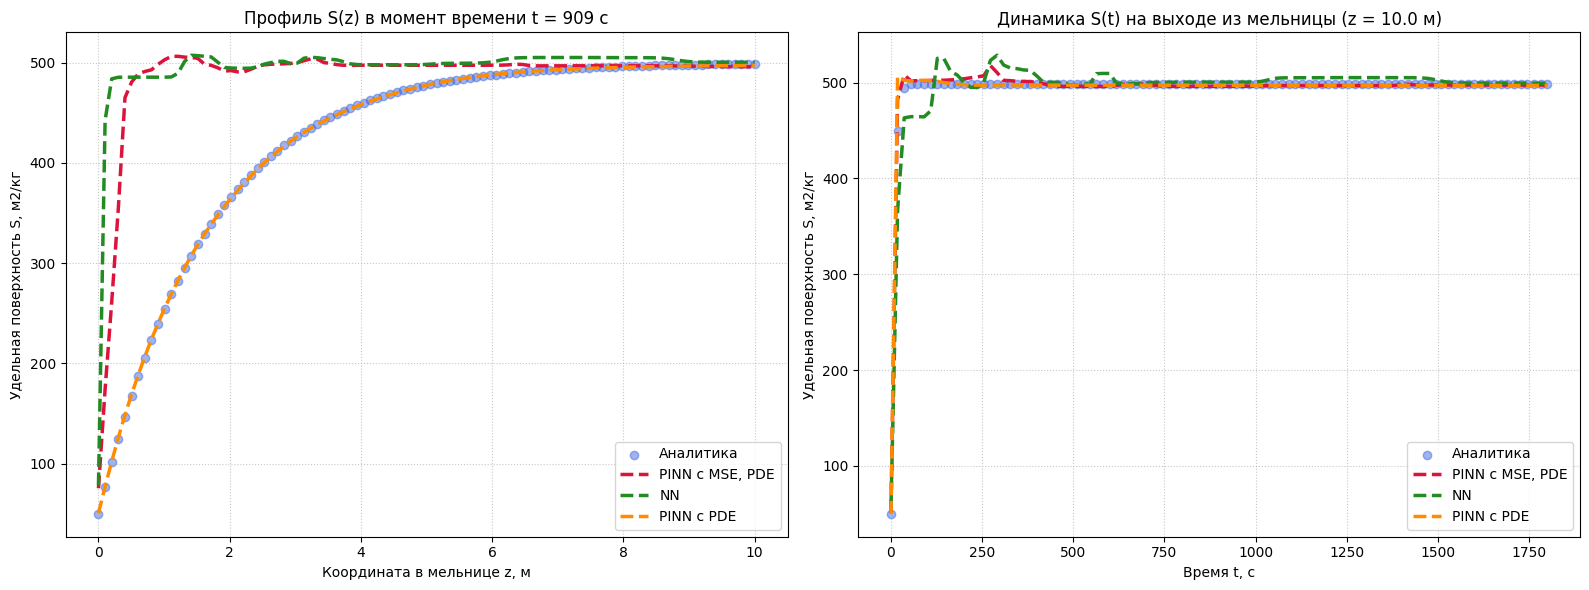

In [54]:
my_models = {
    "PINN с MSE, PDE": pinn_mse_pde,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

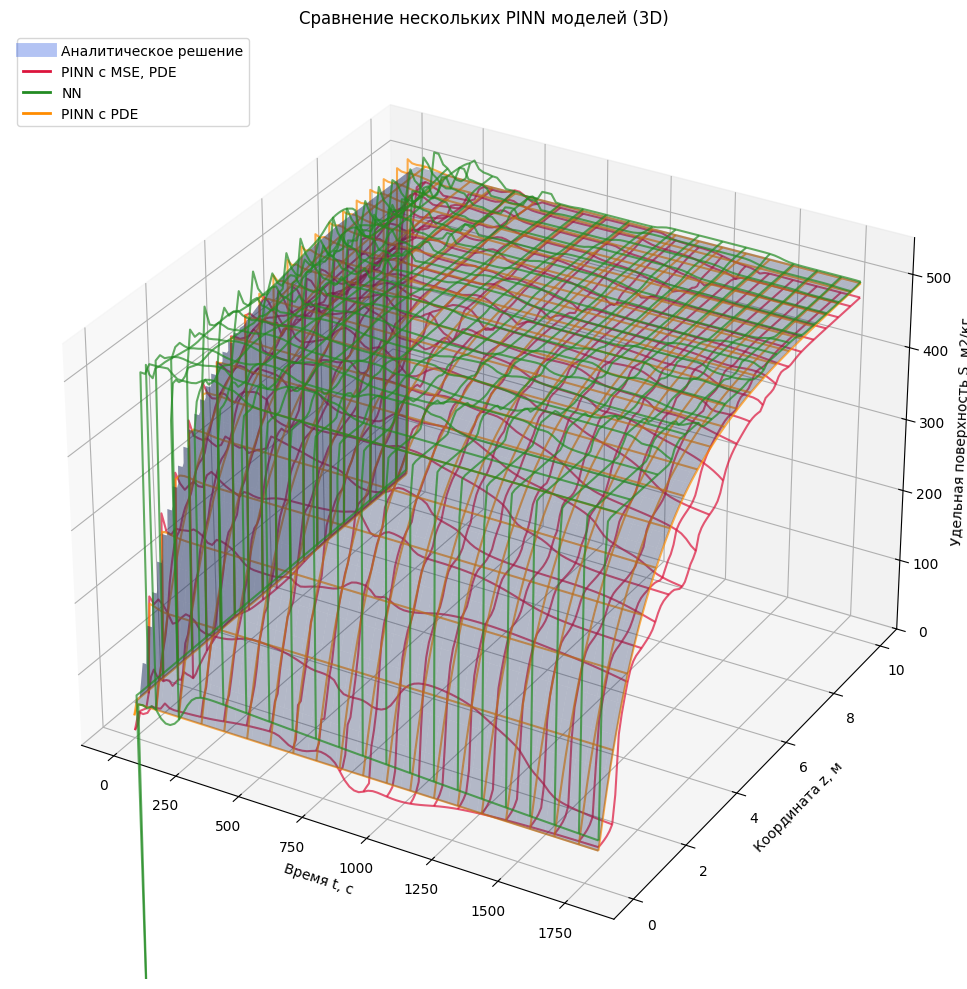

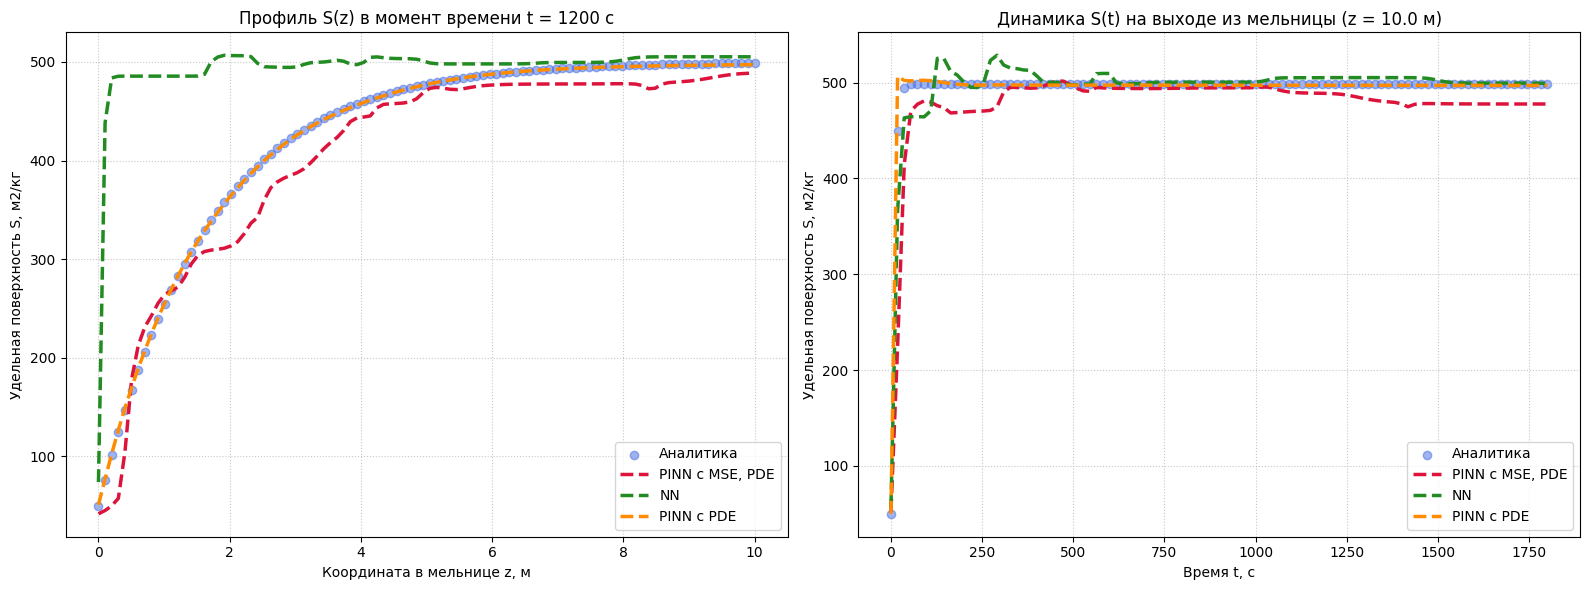

In [ ]:
my_models = {
    "PINN с MSE, PDE": pinn_mse_pde,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

In [200]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=4.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 525767.438
Epoch 100 | Loss: 483639.594
Epoch 200 | Loss: 455922.219
Epoch 300 | Loss: 430683.500
Epoch 400 | Loss: 407361.594
Epoch 500 | Loss: 385737.219
Epoch 600 | Loss: 365668.750
Epoch 700 | Loss: 346949.719
Epoch 800 | Loss: 328552.500
Epoch 900 | Loss: 311549.312
Epoch 1000 | Loss: 295616.188
Epoch 1100 | Loss: 280706.969
Epoch 1200 | Loss: 266777.344
Epoch 1300 | Loss: 253782.406
Epoch 1400 | Loss: 234616.469
Epoch 1500 | Loss: 219437.219
Epoch 1600 | Loss: 205671.922
Epoch 1700 | Loss: 192694.000
Epoch 1800 | Loss: 180390.078
Epoch 1900 | Loss: 168710.438
Epoch 2000 | Loss: 157673.500
Epoch 2100 | Loss: 147197.641
Epoch 2200 | Loss: 137324.328
Epoch 2300 | Loss: 128224.344
Epoch 2400 | Loss: 119308.891
Epoch 2500 | Loss: 110915.219
Epoch 2600 | Loss: 102982.062
Epoch 2700 | Loss: 95532.789
Epoch 2800 | Loss: 88520.188
Epoch 2900 | Loss: 81923.180
Epoch 3000 | Loss: 75736.289
Epoch 3100 | Loss: 69919.875
Epoch 3200 | Loss: 64461.551
Epoch 3

In [215]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

In [212]:
S_preddd = pinn_mse.predict(data['t_test'], data['z_test']) 
S_preddd - S_test

tensor([[ -50.1896,  -50.1896,  -50.1896,  ...,  -50.1896,  -50.1896,
          -50.1896],
        [ -49.5080,  -75.9708, -100.8773,  ..., -448.7317, -448.7317,
         -448.7317],
        [ -49.4998,  -75.9625, -100.8690,  ..., -493.7704, -493.7704,
         -493.7704],
        ...,
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837],
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837],
        [ -49.4992,  -75.9619, -100.8685,  ..., -498.2400, -498.3141,
         -498.3837]])

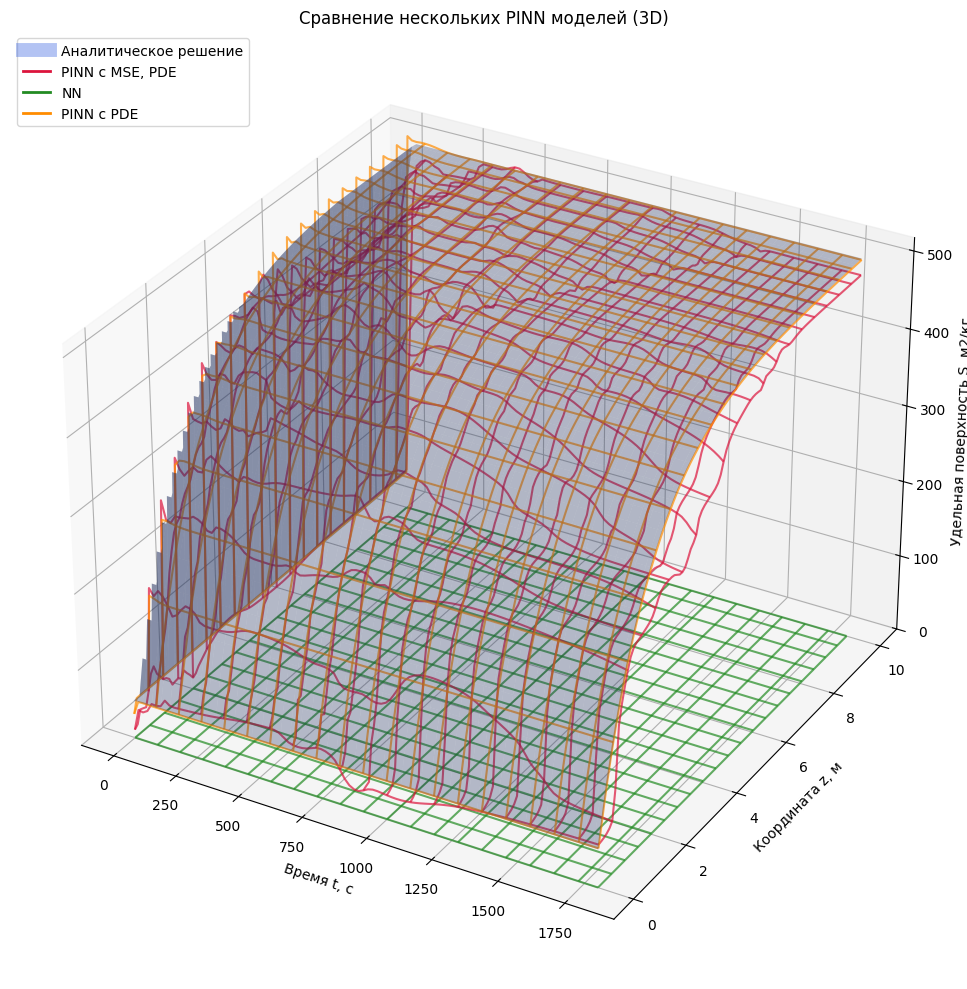

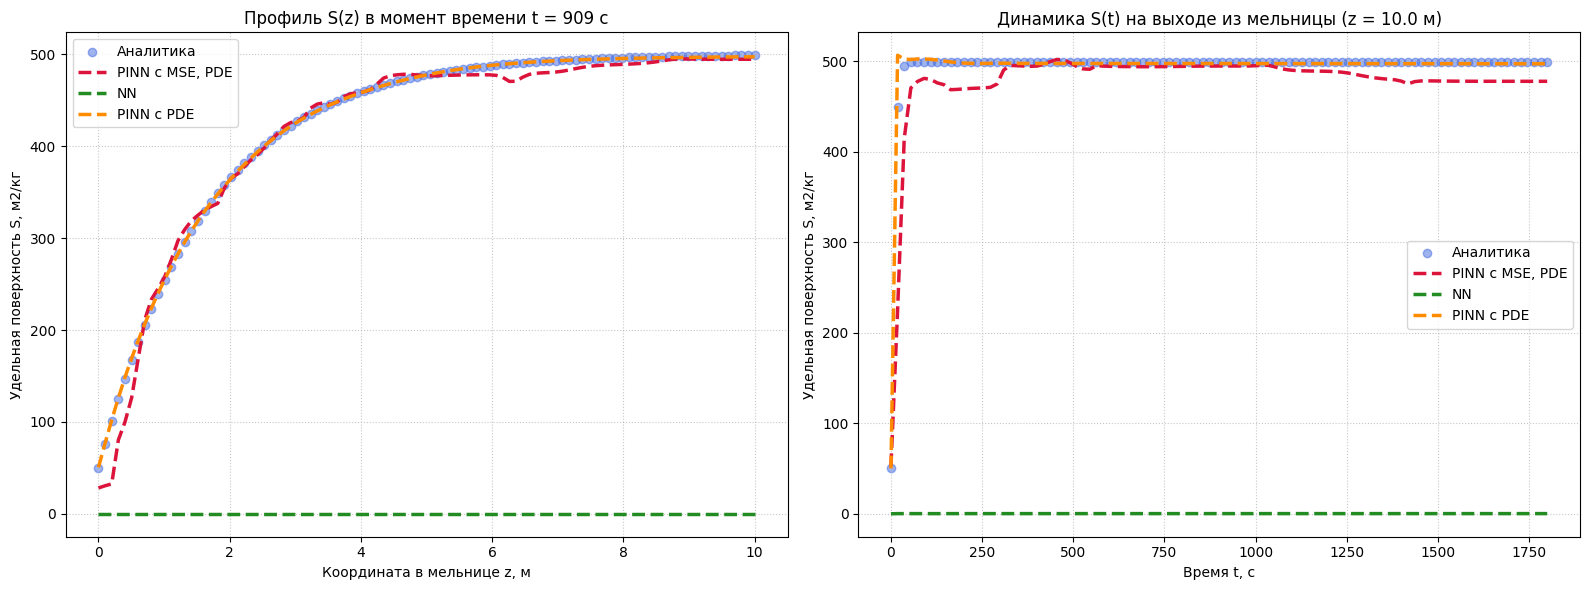

In [214]:
my_models = {
    "PINN с MSE, PDE": pinn,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

## PINN с MSE и обучаемыми параметрами

Обучение PINN с MSE и обучаемыми параметрами k (k_real = 0.12), v_m (v_m_real = 0.2)

In [4]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []
parametr_k = []
list_v = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(40_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=2.,
        lambda_bc=20.,
        lambda_ic=20.,
        lambda_mse=30,
    )
    # if epoch != 40_000:
    #     loss.backward(retain_graph=True)
    # else:
    #     loss.backward()
    loss.backward()
    optimizer.step()

    history.append(loss.item())
    parametr_k.append(pinn.k.item())
    list_v.append(pinn.v_m.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k: {pinn.k.item():.3f} | v_m: {pinn.v_m.item():.3f}") 
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 5299948.000 | k: 0.999 | v_m: 0.501
Epoch 100 | Loss: 4825217.500 | k: 0.900 | v_m: 0.534
Epoch 200 | Loss: 4502593.000 | k: 0.802 | v_m: 0.566
Epoch 300 | Loss: 4215770.000 | k: 0.706 | v_m: 0.588
Epoch 400 | Loss: 3957293.500 | k: 0.611 | v_m: 0.605
Epoch 500 | Loss: 3724055.500 | k: 0.519 | v_m: 0.618
Epoch 600 | Loss: 3513875.750 | k: 0.430 | v_m: 0.631
Epoch 700 | Loss: 3324122.500 | k: 0.342 | v_m: 0.644
Epoch 800 | Loss: 3136263.000 | k: 0.258 | v_m: 0.654
Epoch 900 | Loss: 2968159.750 | k: 0.177 | v_m: 0.660
Epoch 1000 | Loss: 2814634.750 | k: 0.098 | v_m: 0.720
Epoch 1100 | Loss: 2609660.750 | k: 0.023 | v_m: 1.221
Epoch 1200 | Loss: 2432115.500 | k: -0.048 | v_m: 1.538
Epoch 1300 | Loss: 2283143.750 | k: -0.115 | v_m: 1.715
Epoch 1400 | Loss: 2136474.750 | k: -0.177 | v_m: 1.843
Epoch 1500 | Loss: 2002513.625 | k: -0.236 | v_m: 1.944
Epoch 1600 | Loss: 1877871.250 | k: -0.292 | v_m: 2.012
Epoch 1700 | Loss: 1760721.875 | k: -0.344 | v_m: 2

KeyboardInterrupt: 

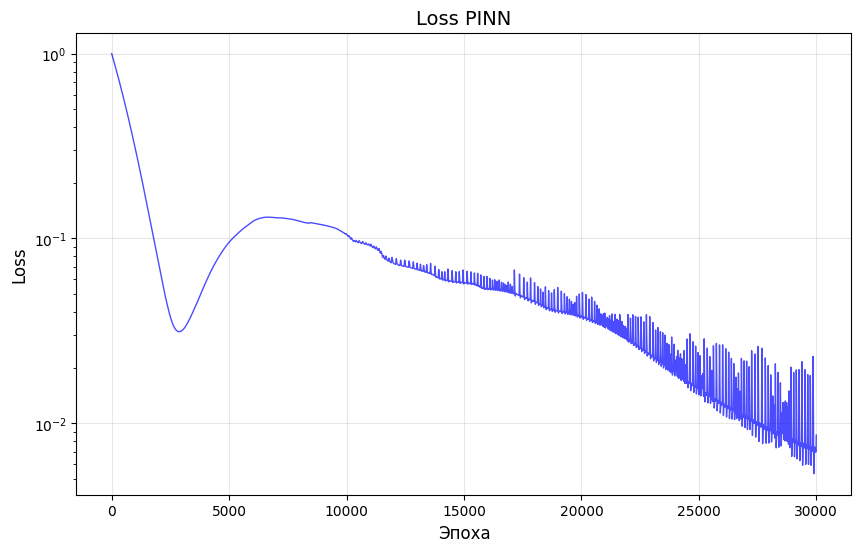

In [11]:
import matplotlib.pyplot as plt

def plot_loss(history):
    """
    Построение графика функции потерь
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history, linewidth=1, color='blue', alpha=0.7)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss PINN', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log') 
    # plt.tight_layout()
    plt.show()

# Вызов после обучения
plot_loss(parametr_k)

# MDN с одним распределением

In [4]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.MDN import MDN
from loss.mdn_loss import mdn_loss

In [5]:
pinn = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [6]:
# --- train ---
t_train = data['t_train']
z_train = data['z_train']
S_train = data['S_train']
# --- test ---
t_test = data['t_test']
z_test = data['z_test']
T, Z = torch.meshgrid(t_test, z_test, indexing='ij')
S_test = data['S_test'].reshape(-1, 1)
S = data['S'].reshape(-1, 1)

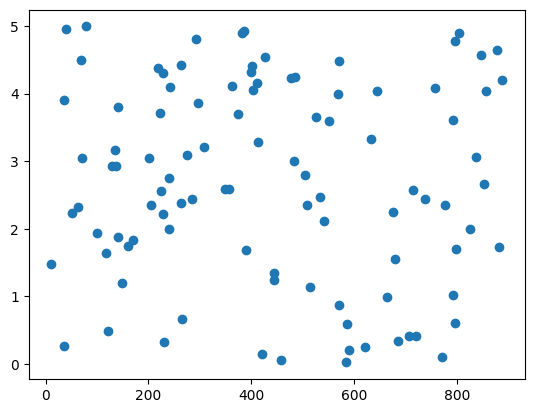

In [10]:
plt.scatter(t_train,z_train)
plt.show()

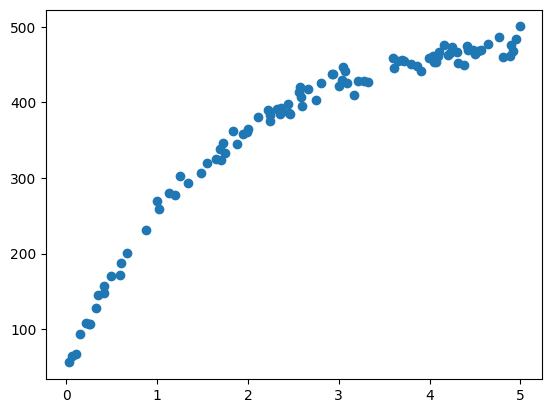

In [22]:
plt.scatter(z_train,S_train)
plt.show()

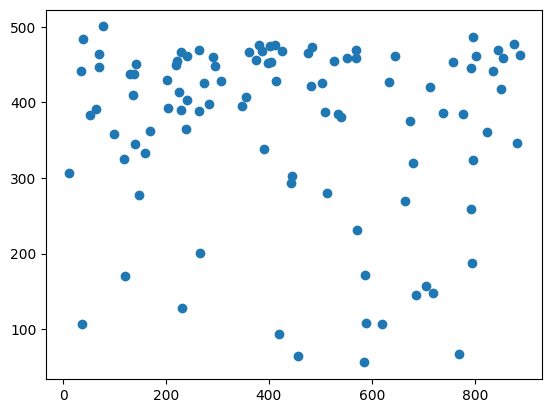

In [23]:
plt.scatter(t_train,S_train)
plt.show()

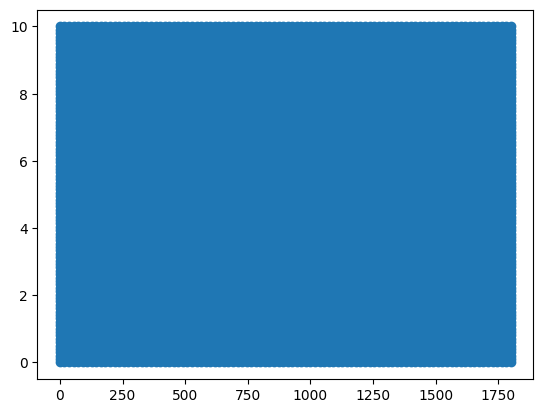

In [11]:
plt.scatter(T,Z)
plt.show()

In [7]:
stacked = torch.stack([T.flatten(), Z.flatten()], dim=1)

T_test, Z_test = stacked[:, 0].reshape(-1, 1), stacked[:, 1].reshape(-1, 1)
print(T_test.shape, Z_test.shape)

torch.Size([10000, 1]) torch.Size([10000, 1])


In [8]:
S_pred_test = pinn.predict(T_test,Z_test)

In [9]:
S_pred_train = pinn.predict(t_train,z_train)

In [10]:
mdn = MDN()
optimizer = torch.optim.Adam(mdn.parameters(), lr=0.001)
epochs = 20_000
mdn_input=torch.cat([t_train, z_train, S_pred_train],dim=1)
residual = S_train-S_pred_train

mdn.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Прямой проход
    mu, sigma = mdn.forward(mdn_input)
    
    # Расчет потерь
    loss = mdn_loss(mu, sigma, residual)
    
    # Обратный проход и шаг
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

Epoch 0/20000, Loss: 306080.6562
Epoch 1000/20000, Loss: 3.2626
Epoch 2000/20000, Loss: 3.2372
Epoch 3000/20000, Loss: 3.2248
Epoch 4000/20000, Loss: 3.2181
Epoch 5000/20000, Loss: 3.2147
Epoch 6000/20000, Loss: 3.2124
Epoch 7000/20000, Loss: 3.2109
Epoch 8000/20000, Loss: 3.2101
Epoch 9000/20000, Loss: 3.2096
Epoch 10000/20000, Loss: 3.2097
Epoch 11000/20000, Loss: 3.2094
Epoch 12000/20000, Loss: 3.2098
Epoch 13000/20000, Loss: 3.2093
Epoch 14000/20000, Loss: 3.2094
Epoch 15000/20000, Loss: 3.2093
Epoch 16000/20000, Loss: 3.2093
Epoch 17000/20000, Loss: 3.2092
Epoch 18000/20000, Loss: 3.2096
Epoch 19000/20000, Loss: 3.2092


In [16]:
print(T.shape, t_train.shape)

torch.Size([100, 100]) torch.Size([100, 1])


In [17]:
print(Z.shape, z_train.shape)

torch.Size([100, 100]) torch.Size([100, 1])


In [36]:
mdn_input=torch.cat([T_test, Z_test, S_pred_test],dim=1)
mean, lower, upper = mdn.predict(mdn_input)
print(mean.shape, lower.shape, upper.shape)
mean, lower, upper = mean.unsqueeze(-1)+S_pred_test, lower.unsqueeze(-1)+S_pred_test, upper.unsqueeze(-1)+S_pred_test

torch.Size([10000]) torch.Size([10000]) torch.Size([10000])


In [35]:
mean.shape

torch.Size([10000, 1])

In [33]:
stacked = torch.stack([mean.flatten(),lower.flatten(), upper.flatten()], dim=1)

mean, lower, upper = stacked[:, 0].reshape(-1, 1), stacked[:, 1].reshape(-1, 1), stacked[:, 2].reshape(-1, 1)
print(mean.shape, lower.shape, upper.shape,)

torch.Size([10000, 1]) torch.Size([10000, 1]) torch.Size([10000, 1])


ValueError: 'yerr' (shape: (2, 10000, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (10000, 1))

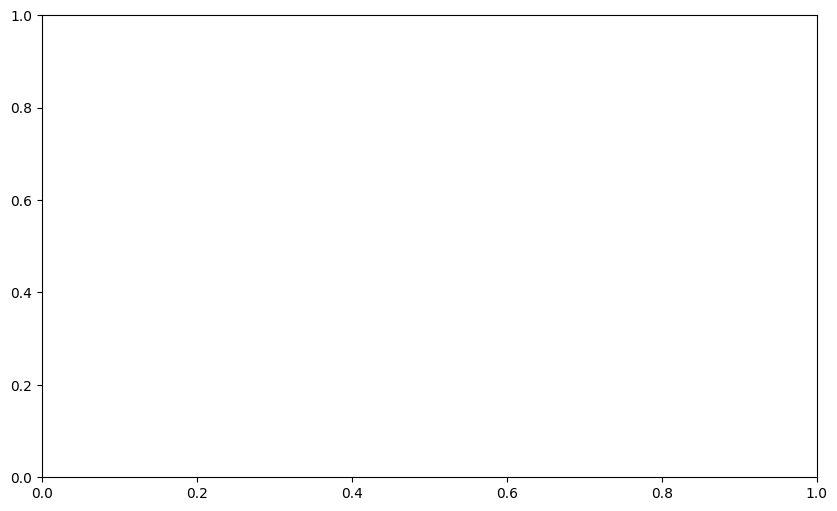

In [37]:
plt.figure(figsize=(10, 6))
# --- 2. MDN предсказание ---
plt.errorbar(
    T_test,
    mean,
    yerr=[lower, upper],
    fmt='o',
    color='red',
    ecolor='red',
    elinewidth=1,
    capsize=3,
    markersize=4,
    label='MDN'
)

# --- 2. PINN предсказание ---
plt.scatter(
    T_test,
    S_pred_test,
    color='blue',
    linewidth=2,
    label='PINN'
)

# --- 3. Реальные данные ---
plt.scatter(
    T_test,
    S_test,
    color='black',
    s=15,
    alpha=0.6,
    label='Данные'
)

plt.xlabel('Время t, с')
plt.ylabel('Удельная поверхность S')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [41]:
error = S_pred_test - mean
mse = torch.mean(error**2).item()
mae = torch.mean(torch.abs(error)).item()
rmse = torch.sqrt(torch.mean(error**2)).item()

print(f'--- Метрики среднего значения ---\nMSE: {mse:.2f}, \nMAE: {mae:.2f}, \nRMSE: {rmse:.2f}')

--- Метрики среднего значения ---
MSE: 2.22, 
MAE: 1.23, 
RMSE: 1.49


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def regression_metrics(model, x, S_pred, S_true):
    model.eval()

    mu, sigma = model(x)
    y_hat = S_pred.squeeze() + mu

    y_true = S_true.squeeze()

    # ошибки
    error = y_true - y_hat

    mse = torch.mean(error**2).item()
    mae = torch.mean(torch.abs(error)).item()
    rmse = torch.sqrt(torch.mean(error**2)).item()

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse
    }